# Vague Benchmark Analysis

Cells in order:
1. Setup — imports, llm_fn configuration
2. LongBench — compare_all on qasper, F1 bar chart
3. Needle heatmap — run_needle_sweep, seaborn heatmap
4. Compression analysis — compression_ratio vs F1 scatter
5. Summary table — markdown table of all EvalResult fields

In [1]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────
import os, sys, random
import numpy as np
from dotenv import load_dotenv
load_dotenv()

# Ensure project root is importable when running from notebooks/
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Determinism
random.seed(42)
np.random.seed(42)

# Results directory
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'benchmarks', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
CACHE_DIR = os.path.join(PROJECT_ROOT, '.cache')
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Plug in your LLM here ──────────────────────────────────────────────────
# llm_fn must be Callable[[str], str]  (prompt in, completion out).
#
# Example 1 — OpenAI
# import openai
# client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])
# def llm_fn(prompt: str) -> str:
#     r = client.chat.completions.create(
#         model='gpt-4o-mini',
#         messages=[{'role': 'user', 'content': prompt}],
#         max_tokens=256,
#     )
#     return r.choices[0].message.content
#
# Example 2 — Anthropic
import anthropic
client = anthropic.Anthropic(api_key=os.environ['ANTHROPIC_API_KEY'])
def llm_fn(prompt: str) -> str:
     r = client.messages.create(
         model='claude-3-haiku-20240307',
         max_tokens=256,
         messages=[{'role': 'user', 'content': prompt}],
     )
     return r.content[0].text
#
# Example 3 — local Ollama
# import requests
# def llm_fn(prompt: str) -> str:
#     r = requests.post('http://localhost:11434/api/generate',
#                       json={'model': 'llama3', 'prompt': prompt, 'stream': False})
#     return r.json()['response']

print('Setup complete.')
print('RESULTS_DIR:', RESULTS_DIR)

Setup complete.
RESULTS_DIR: /Users/lorenzopastore/Desktop/Dev/Personal/vague/benchmarks/results


qasper/vague:   0%|                                                                                | 0/50 [00:00<?, ?sample/s]/Users/lorenzopastore/Desktop/Dev/Personal/vague/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
qasper/full_context: 100%|████████████████████████████████████████████████████████████████| 50/50 [03:23<00:00,  4.07s/sample]


vague            F1=0.120  tokens=1721  cr=2.86  latency=4122.1ms
naive_rag        F1=0.126  tokens=1706  cr=1.00  latency=3046.0ms
full_context     F1=0.116  tokens=3748  cr=1.00  latency=4066.4ms


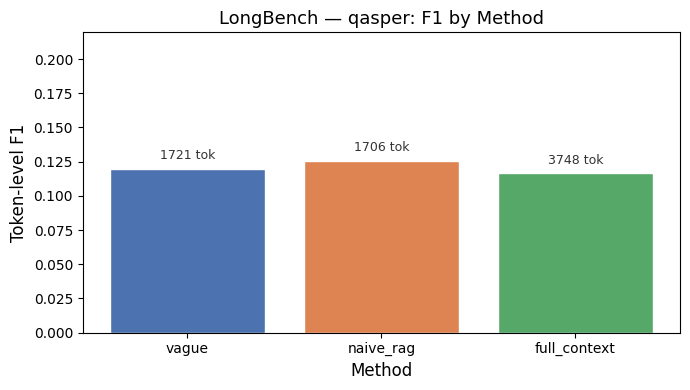

Saved: /Users/lorenzopastore/Desktop/Dev/Personal/vague/benchmarks/results/longbench_qasper_f1.png


In [2]:
# ── Cell 2: LongBench — compare_all on qasper ──────────────────────────────
from benchmarks.longbench import LongBenchEval, EvalResult

N_SAMPLES = 50   # increase to 200 for publication-quality results

evaluator = LongBenchEval(llm_fn=llm_fn, cache_dir=CACHE_DIR)
results: list[EvalResult] = evaluator.compare_all(task='qasper', n_samples=N_SAMPLES)

for r in results:
    print(f'{r.method:15s}  F1={r.f1_score:.3f}  '
          f'tokens={r.avg_input_tokens}  '
          f'cr={r.compression_ratio:.2f}  '
          f'latency={r.latency_ms:.1f}ms')

# Bar chart: F1 vs method, annotated with avg token counts
methods      = [r.method for r in results]
f1_scores    = [r.f1_score for r in results]
token_counts = [r.avg_input_tokens for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    methods, f1_scores,
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='white',
)
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Token-level F1', fontsize=12)
ax.set_title('LongBench — qasper: F1 by Method', fontsize=13)
top = max(f1_scores) if f1_scores else 1.0
ax.set_ylim(0, min(1.05, top * 1.35 + 0.05))

for bar, tok in zip(bars, token_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{tok} tok',
        ha='center', va='bottom', fontsize=9, color='#333333',
    )

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'longbench_qasper_f1.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('Saved:', out_path)

needle sweep: 100%|█████████████████████████████████████████████████████████████████████████| 35/35 [09:19<00:00, 15.98s/cell]


 context_length  position  found_rate  tokens_used
            512      0.00         0.6          526
            512      0.10         0.6          527
            512      0.25         0.8          527
            512      0.50         0.8          527
            512      0.75         1.0          526
            512      0.90         0.8          526
            512      1.00         0.6          526
           1024      0.00         0.4         1041
           1024      0.10         1.0         1041
           1024      0.25         0.8         1041
           1024      0.50         1.0         1041
           1024      0.75         0.8         1041
           1024      0.90         1.0         1041
           1024      1.00         0.8         1040
           2048      0.00         0.2         1650
           2048      0.10         0.8         1650
           2048      0.25         1.0         1650
           2048      0.50         1.0         1650
           2048      0.75      

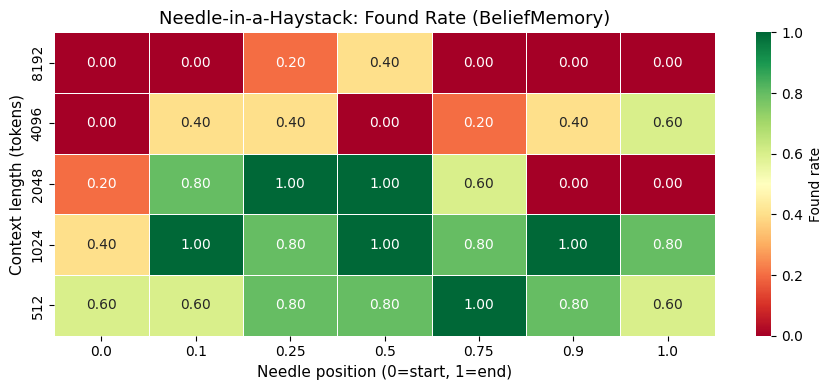

Saved: /Users/lorenzopastore/Desktop/Dev/Personal/vague/benchmarks/results/needle_heatmap.png


In [3]:
# ── Cell 3: Needle heatmap ─────────────────────────────────────────────────
from benchmarks.needle import run_needle_sweep

CONTEXT_LENGTHS = [512, 1024, 2048, 4096, 8192]
POSITIONS       = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

# Pass llm_fn=None to use the always-found mock (structural test).
# Replace with your real llm_fn for actual recall measurements.
sweep_df = run_needle_sweep(
    context_lengths=CONTEXT_LENGTHS,
    positions=POSITIONS,
    llm_fn=llm_fn,
)
print(sweep_df.to_string(index=False))

# Pivot for heatmap (context_length x position)
pivot = sweep_df.pivot(index='context_length', columns='position', values='found_rate')
pivot = pivot.sort_index(ascending=False)   # longest context at top

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={'label': 'Found rate'},
)
ax.set_title('Needle-in-a-Haystack: Found Rate (BeliefMemory)', fontsize=13)
ax.set_xlabel('Needle position (0=start, 1=end)', fontsize=11)
ax.set_ylabel('Context length (tokens)', fontsize=11)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'needle_heatmap.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('Saved:', out_path)

Running vague n_components=8 ...


qasper/vague: 100%|███████████████████████████████████████████████████████████████████████| 30/30 [01:33<00:00,  3.12s/sample]


  F1=0.104  cr=2.971  tokens=1682
Running vague n_components=16 ...


qasper/vague: 100%|███████████████████████████████████████████████████████████████████████| 30/30 [01:20<00:00,  2.69s/sample]


  F1=0.118  cr=2.938  tokens=1698
Running vague n_components=32 ...


...

  F1=0.116  cr=2.938  tokens=1698
Running vague n_components=64 ...


qasper/vague: 100%|███████████████████████████████████████████████████████████████████████| 30/30 [01:28<00:00,  2.97s/sample]


  F1=0.120  cr=2.938  tokens=1698
Running vague n_components=128 ...


qasper/vague: 100%|███████████████████████████████████████████████████████████████████████| 30/30 [01:25<00:00,  2.86s/sample]


  F1=0.110  cr=2.938  tokens=1698


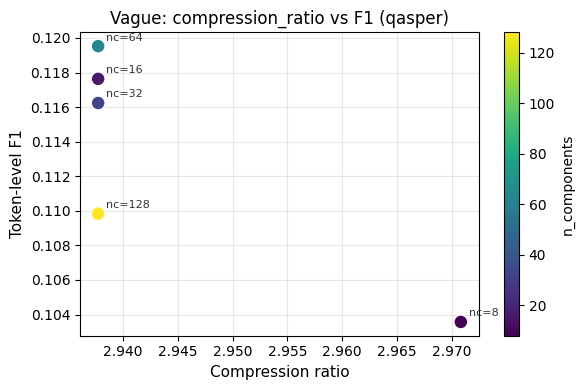

Saved: /Users/lorenzopastore/Desktop/Dev/Personal/vague/benchmarks/results/compression_vs_f1.png


In [4]:
# ── Cell 4: Compression analysis — scatter (compression_ratio vs F1) ───────
N_COMPONENTS_GRID = [8, 16, 32, 64, 128]
TASK = 'qasper'
N_SAMPLES_COMP = 30   # keep quick; increase for statistical confidence

comp_results = []
for nc in N_COMPONENTS_GRID:
    print(f'Running vague n_components={nc} ...')
    r = evaluator.run(
        task=TASK, method='vague',
        n_components=nc, n_samples=N_SAMPLES_COMP,
    )
    comp_results.append(r)
    print(f'  F1={r.f1_score:.3f}  cr={r.compression_ratio:.3f}  tokens={r.avg_input_tokens}')

crs    = [r.compression_ratio for r in comp_results]
f1s    = [r.f1_score for r in comp_results]
labels = [str(nc) for nc in N_COMPONENTS_GRID]

fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(
    crs, f1s,
    c=N_COMPONENTS_GRID, cmap='viridis',
    s=100, zorder=3, edgecolors='white',
)
for x, y, lbl in zip(crs, f1s, labels):
    ax.annotate(
        f'nc={lbl}', (x, y),
        textcoords='offset points', xytext=(6, 4),
        fontsize=8, color='#333333',
    )

plt.colorbar(sc, ax=ax, label='n_components')
ax.set_xlabel('Compression ratio', fontsize=11)
ax.set_ylabel('Token-level F1', fontsize=11)
ax.set_title(f'Vague: compression_ratio vs F1 ({TASK})', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'compression_vs_f1.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('Saved:', out_path)

## Cell 5: Summary Table — All EvalResult Fields

Run the code cell below to generate the markdown table from all collected results.

Fields: `task`, `method`, `f1_score`, `avg_input_tokens`, `compression_ratio`, `latency_ms`, `n_samples`

In [5]:
# ── Cell 5: Summary table ──────────────────────────────────────────────────
from IPython.display import Markdown, display
import dataclasses

all_results = results + comp_results

header = '| task | method | f1_score | avg_input_tokens | compression_ratio | latency_ms | n_samples |'
sep    = '|------|--------|----------|-----------------|-------------------|------------|-----------|'
rows   = []
for r in all_results:
    rows.append(
        f'| {r.task} | {r.method} | {r.f1_score:.3f} '
        f'| {r.avg_input_tokens} '
        f'| {r.compression_ratio:.3f} '
        f'| {r.latency_ms:.1f} '
        f'| {r.n_samples} |'
    )

table = '\n'.join([header, sep] + rows)
display(Markdown(table))
print(table)

| task | method | f1_score | avg_input_tokens | compression_ratio | latency_ms | n_samples |
|------|--------|----------|-----------------|-------------------|------------|-----------|
| qasper | vague | 0.120 | 1721 | 2.861 | 4122.1 | 50 |
| qasper | naive_rag | 0.126 | 1706 | 1.000 | 3046.0 | 50 |
| qasper | full_context | 0.116 | 3748 | 1.000 | 4066.4 | 50 |
| qasper | vague | 0.104 | 1682 | 2.971 | 3123.2 | 30 |
| qasper | vague | 0.118 | 1698 | 2.938 | 2687.6 | 30 |
| qasper | vague | 0.116 | 1698 | 2.938 | 2763.7 | 30 |
| qasper | vague | 0.120 | 1698 | 2.938 | 2964.3 | 30 |
| qasper | vague | 0.110 | 1698 | 2.938 | 2863.4 | 30 |

| task | method | f1_score | avg_input_tokens | compression_ratio | latency_ms | n_samples |
|------|--------|----------|-----------------|-------------------|------------|-----------|
| qasper | vague | 0.120 | 1721 | 2.861 | 4122.1 | 50 |
| qasper | naive_rag | 0.126 | 1706 | 1.000 | 3046.0 | 50 |
| qasper | full_context | 0.116 | 3748 | 1.000 | 4066.4 | 50 |
| qasper | vague | 0.104 | 1682 | 2.971 | 3123.2 | 30 |
| qasper | vague | 0.118 | 1698 | 2.938 | 2687.6 | 30 |
| qasper | vague | 0.116 | 1698 | 2.938 | 2763.7 | 30 |
| qasper | vague | 0.120 | 1698 | 2.938 | 2964.3 | 30 |
| qasper | vague | 0.110 | 1698 | 2.938 | 2863.4 | 30 |


=== qasper ===


qasper/vague:   0%|                                                                                | 0/50 [00:00<?, ?sample/s]/Users/lorenzopastore/Desktop/Dev/Personal/vague/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
qasper/full_context: 100%|████████████████████████████████████████████████████████████████| 50/50 [02:19<00:00,  2.79s/sample]


  vague            F1=0.117  tokens=1721  cr=2.86x
  naive_rag        F1=0.124  tokens=1706  cr=1.00x
  full_context     F1=0.115  tokens=3748  cr=1.00x
=== hotpotqa ===


hotpotqa/naive_rag:   0%|                                                                          | 0/50 [00:00<?, ?sample/s]'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 5108e650-c796-4b29-b518-7eb7821735ea)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json
Retrying in 1s [Retry 1/5].
hotpotqa/full_context: 100%|██████████████████████████████████████████████████████████████| 50/50 [01:55<00:00,  2.30s/sample]


  vague            F1=0.033  tokens=1782  cr=7.31x
  naive_rag        F1=0.035  tokens=1764  cr=1.00x
  full_context     F1=0.033  tokens=4120  cr=1.00x
=== multifieldqa_en ===


multifieldqa_en/full_context: 100%|███████████████████████████████████████████████████████| 50/50 [02:08<00:00,  2.58s/sample]


  vague            F1=0.131  tokens=2257  cr=3.64x
  naive_rag        F1=0.136  tokens=2232  cr=1.00x
  full_context     F1=0.124  tokens=3768  cr=1.00x


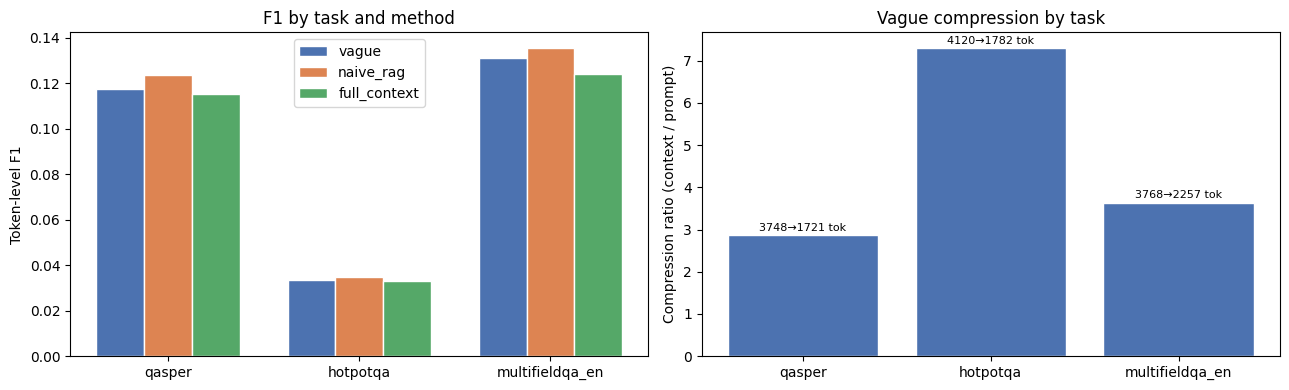

Saved: /Users/lorenzopastore/Desktop/Dev/Personal/vague/benchmarks/results/multitask_benchmark.png


In [2]:
# ── Cell 6: Multi-task benchmark — hotpotqa + multifieldqa_en ──────────────
from benchmarks.longbench import LongBenchEval, EvalResult
import matplotlib.pyplot as plt
import numpy as np

TASKS = ["qasper", "hotpotqa", "multifieldqa_en"]
N = 50

all_task_results: dict[str, list[EvalResult]] = {}

for task in TASKS:
    print(f"=== {task} ===")
    ev = LongBenchEval(llm_fn=llm_fn, cache_dir=CACHE_DIR)
    task_results = ev.compare_all(task=task, n_samples=N)
    all_task_results[task] = task_results
    for r in task_results:
        print(f"  {r.method:15s}  F1={r.f1_score:.3f}  tokens={r.avg_input_tokens}  cr={r.compression_ratio:.2f}x")

# Grouped bar chart: F1 by method, grouped by task
methods = ["vague", "naive_rag", "full_context"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x = np.arange(len(TASKS))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# F1
ax = axes[0]
for i, (method, color) in enumerate(zip(methods, colors)):
    vals = [next(r.f1_score for r in all_task_results[t] if r.method == method) for t in TASKS]
    ax.bar(x + i * width, vals, width, label=method, color=color, edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(TASKS)
ax.set_ylabel("Token-level F1")
ax.set_title("F1 by task and method")
ax.legend()

# Compression ratio (vague only)
ax = axes[1]
cr_vals = [next(r.compression_ratio for r in all_task_results[t] if r.method == "vague") for t in TASKS]
tok_full = [next(r.avg_input_tokens for r in all_task_results[t] if r.method == "full_context") for t in TASKS]
tok_vague = [next(r.avg_input_tokens for r in all_task_results[t] if r.method == "vague") for t in TASKS]
bars = ax.bar(TASKS, cr_vals, color="#4C72B0", edgecolor="white")
for bar, tf, tv in zip(bars, tok_full, tok_vague):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{tf}→{tv} tok", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Compression ratio (context / prompt)")
ax.set_title("Vague compression by task")

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, "multitask_benchmark.png")
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)
